In [122]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns


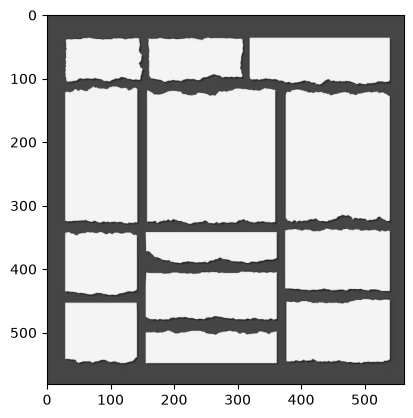

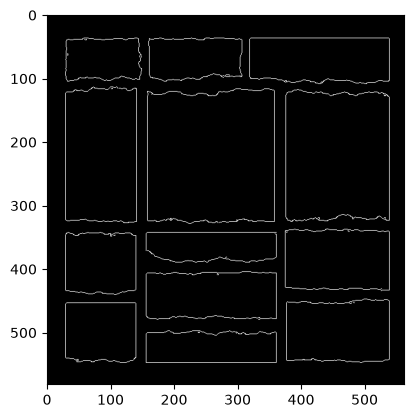

In [123]:
image_path = r'D:\PythonProject1\Intern\Images\img12.png'
image = cv2.imread(image_path)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray_image, (3,3), 0)
_, thresh = cv2.threshold(gray_image, 240, 245, cv2.THRESH_BINARY_INV)
canny = cv2.Canny(thresh,50,150)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()
plt.imshow(canny, cmap='gray')
plt.show()

In [124]:
_, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY) 

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
contours, hierarchy = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
min_area = 500 
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]
contour_img = image.copy()
cv2.drawContours(contour_img, valid_contours, -1, (0, 255, 0), 3)


array([[[69, 69, 69],
        [69, 69, 69],
        [69, 69, 69],
        ...,
        [69, 69, 69],
        [69, 69, 69],
        [69, 69, 69]],

       [[69, 69, 69],
        [69, 69, 69],
        [69, 69, 69],
        ...,
        [69, 69, 69],
        [69, 69, 69],
        [69, 69, 69]],

       [[69, 69, 69],
        [69, 69, 69],
        [69, 69, 69],
        ...,
        [69, 69, 69],
        [69, 69, 69],
        [69, 69, 69]],

       ...,

       [[69, 69, 69],
        [69, 69, 69],
        [69, 69, 69],
        ...,
        [69, 69, 69],
        [69, 69, 69],
        [69, 69, 69]],

       [[69, 69, 69],
        [69, 69, 69],
        [69, 69, 69],
        ...,
        [69, 69, 69],
        [69, 69, 69],
        [69, 69, 69]],

       [[69, 69, 69],
        [69, 69, 69],
        [69, 69, 69],
        ...,
        [69, 69, 69],
        [69, 69, 69],
        [69, 69, 69]]], shape=(582, 562, 3), dtype=uint8)

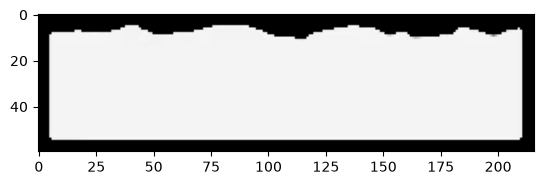

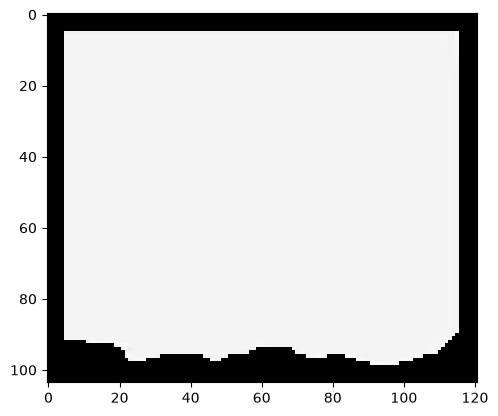

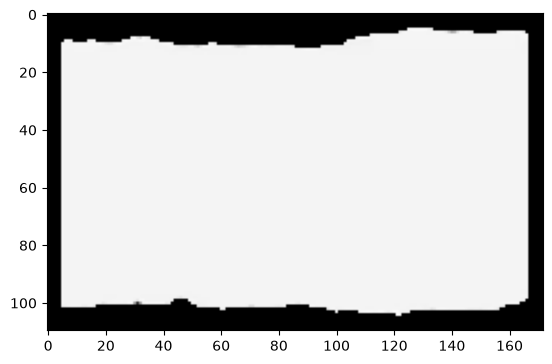

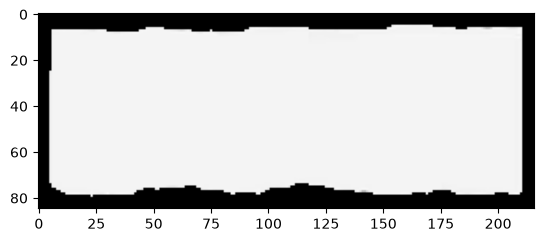

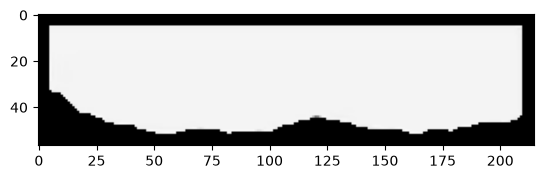

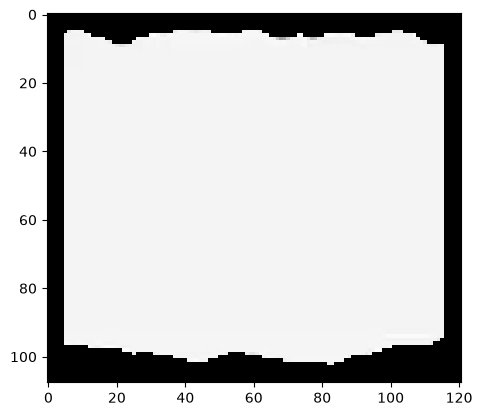

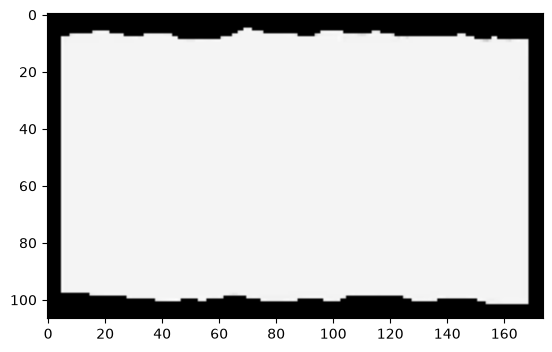

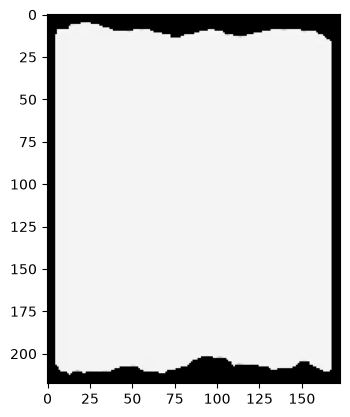

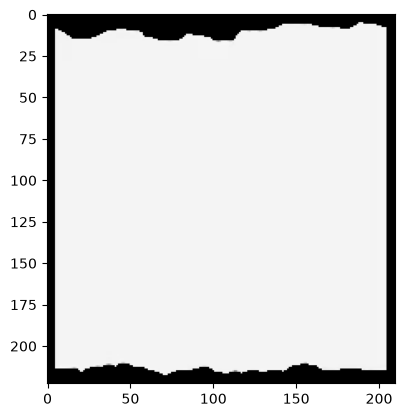

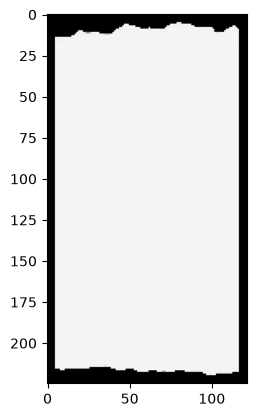

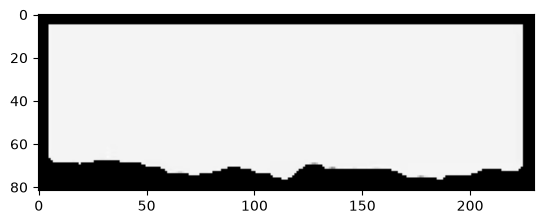

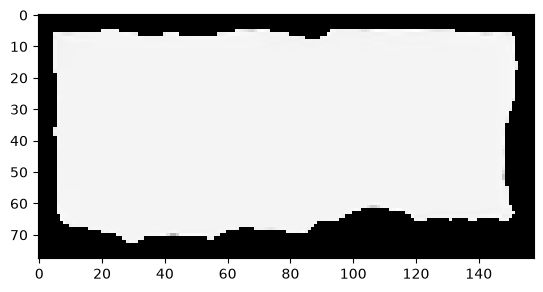

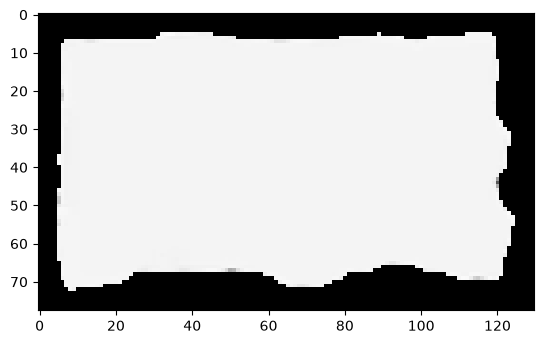

In [125]:
isolated_pieces_list = []  
count=0
for contour in valid_contours: 
    x, y, w, h = cv2.boundingRect(contour)
    pad = 5
    
    x_start, x_end = max(0, x - pad), min(image.shape[1], x + w + pad)
    y_start, y_end = max(0, y - pad), min(image.shape[0], y + h + pad)
    
    cropped_piece = image[y_start:y_end, x_start:x_end]
    
    mask = np.zeros_like(closed)
    cv2.drawContours(mask, [contour], -1, 255, -1) 

    cropped_mask = mask[y_start:y_end, x_start:x_end]
    
    isolated_piece = cv2.bitwise_and(cropped_piece, cropped_piece, mask=cropped_mask)
    
    rgb_piece = cv2.cvtColor(isolated_piece, cv2.COLOR_BGR2RGB)
    isolated_pieces_list.append(rgb_piece)
    count += 1
    plt.imshow(rgb_piece)
    plt.show()

In [126]:
# img_frag1 = isolated_pieces_list[0]
# img_frag2 = isolated_pieces_list[1]

# sift = cv2.SIFT_create()

# kp1, des1 = sift.detectAndCompute(img_frag1, None)
# kp2, des2 = sift.detectAndCompute(img_frag2, None)

# bf = cv2.BFMatcher()
# matches = bf.knnMatch(des1, des2, k=2)

# good_matches = []
# for m, n in matches:
#     if m.distance < 0.75 * n.distance:
#         good_matches.append(m)

# matching_result = cv2.drawMatches(
#     img_frag1, kp1, 
#     img_frag2, kp2, 
#     good_matches, None, 
#     flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
# )

# # Display the feature links
# plt.figure(figsize=(15, 7))
# plt.title(f"Feature Matching: Found {len(good_matches)} good matches")
# plt.imshow(matching_result)
# plt.axis('off')
# plt.show()

In [127]:
import cv2, numpy as np, random, math


In [128]:
def get_shards(img):
    # 1. FIX: Check if the image is already grayscale before converting
    if len(img.shape) == 3 and img.shape[2] == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) 
    else:
        gray = img.copy() 

    gray = cv2.blur(gray, (2, 2))
    canny = cv2.Canny(gray, 30, 150)
    
    # 2. OPTIONAL IMPROVEMENT: Helpful if running in a Jupyter environment
    # cv2.imshow('canny', canny)
    
    # Find contours
    contours, _ = cv2.findContours(canny, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    # Draw contours on canny (this connects the contours)
    cv2.drawContours(canny, contours, -1, 255, 6)
    
    # Get mask for floodfill
    h, w = canny.shape[:2]
    mask = np.zeros((h + 2, w + 2), np.uint8)
    
    # Floodfill from point (0, 0)
    cv2.floodFill(canny, mask, (0, 0), 123)
    
    # 3. FIX: cv2.cvtColor expects a 3-channel input for COLOR_GRAY2BGR, 
    # but canny is 1-channel grayscale. The conversion target should be COLOR_GRAY2BGR.
    hsv = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)
    
    lower, upper = np.array([122, 122, 122]), np.array([124, 124, 124])
    mask = cv2.inRange(hsv, lower, upper)
    
    # Bitwise-AND mask and original image
    res = cv2.bitwise_and(hsv, hsv, mask=mask)
    gray = 255 - cv2.cvtColor(res, cv2.COLOR_BGR2GRAY)
    
    _, thresh = cv2.threshold(gray, 220, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    res = np.zeros_like(res)
    unconnectedContours = []
    
    for contour in contours:
        area = cv2.contourArea(contour)
        # Using the actual dynamically extracted dimensions (h and w)
        if area > 987 and area < (h * w) - 9000:
            # Draw contours as solid white on the 3-channel 'res' image
            cv2.drawContours(res, [contour], 0, (255, 255, 255), cv2.FILLED)
            unconnectedContours.append(contour)
            
    # 4. FIX: Safely grab the contour to avoid IndexError if none match your filters
    if len(unconnectedContours) > 0:
        # Sort by area to safely get the largest matching shard contour
        largest_unconnected = max(unconnectedContours, key=cv2.contourArea)
    else:
        largest_unconnected = None
        print("Warning: No contours matched the area criteria.")

    # 5. FIX: Removed the undefined 'largest_contour(contours)' reference
    print(f"Found {len(unconnectedContours)} valid shard contours.")
    
    return res, largest_unconnected

In [129]:
def lines_mask(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    dst = cv2.Canny(gray, 50, 200, None, 3)
    # Create mask image
    mask = np.zeros_like(gray)
    # Find the lines
    lines = cv2.HoughLines(dst, 1, np.pi / 180, 100, None, 0, 0)
    # Draw the lines
    if lines is not None:
        for i in range(0, len(lines)):
            rho = lines[i][0][0]
            theta = lines[i][0][1]
            a = math.cos(theta)
            b = math.sin(theta)
            x0 = a * rho
            y0 = b * rho
            pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
            pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
            cv2.line(mask, pt1, pt2, 255, 18, cv2.LINE_AA)
    #cv2.imshow('mask', mask)
    return mask


In [130]:
# Takes an image and a contour and returns the torn edge
def find_torn_edge(img, cnt, img_lines):
    # Create a temporary iamge
    img_h, img_w = img.shape[0], img.shape[1]
    temp = np.zeros((img_h, img_w), np.uint8)
    temp_human = np.zeros((img_h, img_w), np.uint8)
    cv2.drawContours(temp_human, [cnt], 0, 78, cv2.FILLED)
    torn_edge = []
    for i in range(len(cnt)):
        x,y = cnt[i][0]
        if img_lines[y,x] == 0: torn_edge.append((x,y))
    #cnt1 = np.array(torn_edge1)
    for i in range(len(torn_edge)-1):
        a = torn_edge[i]
        b = torn_edge[i+1]
        cv2.line(temp, a, b, 255, 2)
        cv2.line(temp_human, a, b, 255, 14)
    return torn_edge, temp_human, temp

Found 5 valid shard contours.


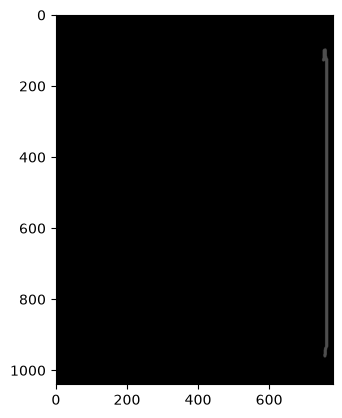

Found 1 valid shard contours.


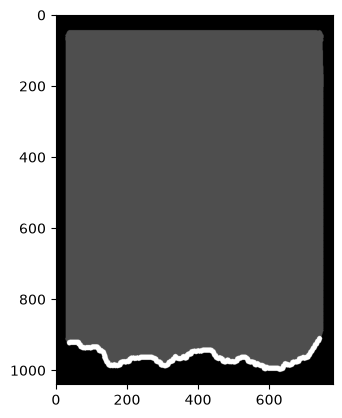

Found 1 valid shard contours.


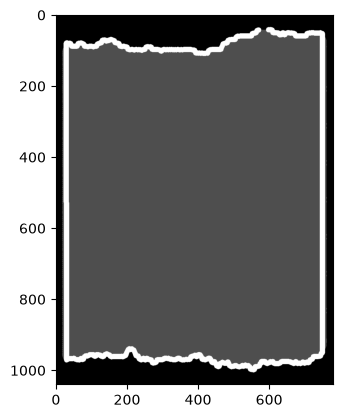

Found 1 valid shard contours.


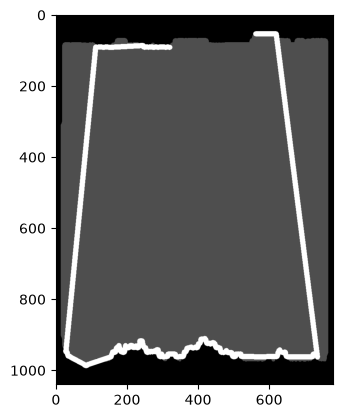

Found 2 valid shard contours.


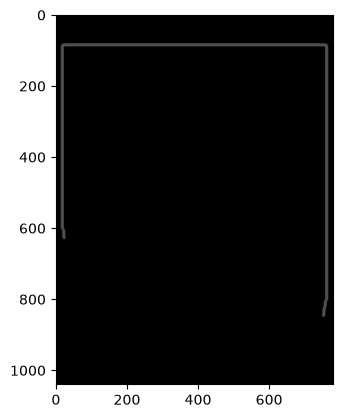

Found 1 valid shard contours.


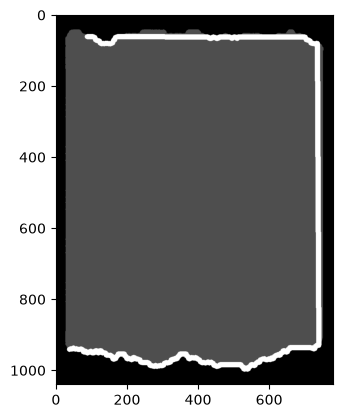

Found 1 valid shard contours.


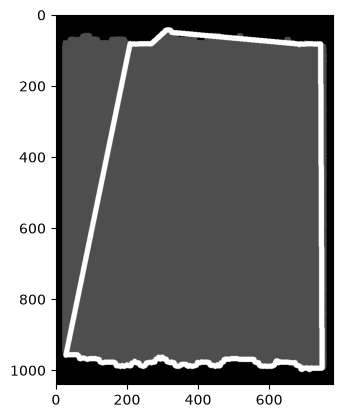

Found 1 valid shard contours.


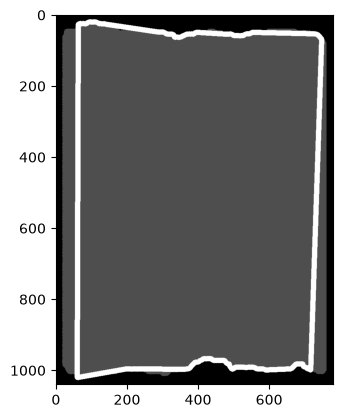

Found 1 valid shard contours.


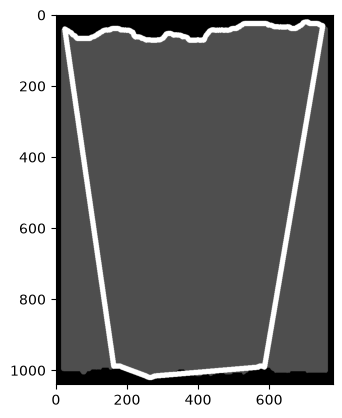

Found 1 valid shard contours.


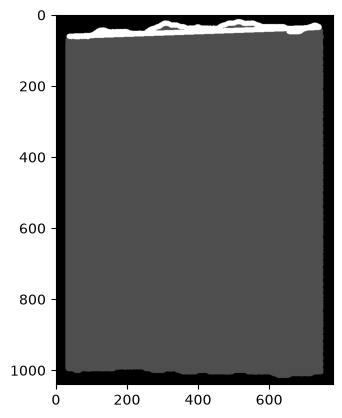

Found 1 valid shard contours.


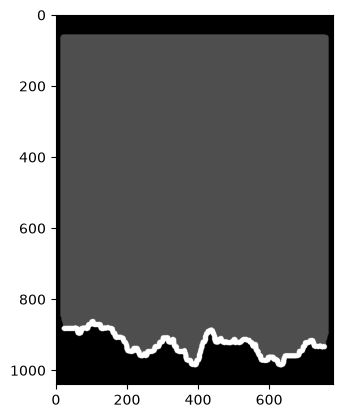

Found 2 valid shard contours.


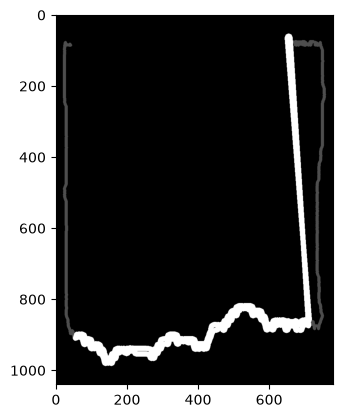

Found 3 valid shard contours.


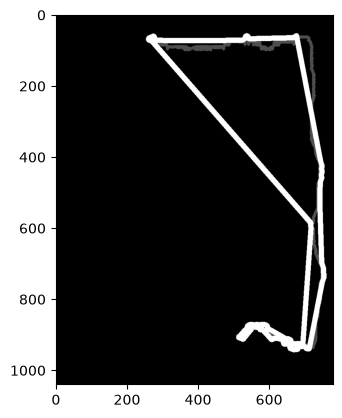

In [131]:

cc=0
for i in isolated_pieces_list:
    if count==cc:
        break
    else:
        img1=i
        img_w, img_h = 780,1040
        img1 = cv2.resize(img1, (img_w, img_h))
        res1, cnt1 = get_shards(img1)
        img1_lines = lines_mask(res1)
        torn_edge1, temp_human1, edge_mask1 = find_torn_edge(img1, cnt1, img1_lines)
        plt.imshow(cv2.cvtColor(temp_human1,cv2.COLOR_BGR2RGB))
        plt.show()

    